<a href="https://colab.research.google.com/github/MaseleCS-afk/carisurg-portfolio/blob/main/week0_triage_eda_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emergency Triage Dataset Visualization - Week 0, Assignment 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings
sns.set(style="whitegrid")

# Define a variable for the Google Drive path after mounting
drive_path = '/content/drive/MyDrive/'

In [ ]:
# Load dataset
df = pd.read_csv(f'{drive_path}EmergencyTriageDataset_Reduced_Dirty.csv')

# Display first 5 rows
df.head()

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,Male,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,Female,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,FEMALE,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0


In [ ]:
# Dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

# Statistical summary
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   object 
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 189.6+ KB
None
ID         0
Age        0
Gender     0
GCS       22
SBP        0
DBP       22
MAP       22
pulse     22
Temp      22
RR        22
Fio2      22
dtype: int64
                ID          Age          DBP          MAP           RR  \
count  2205.000000  2205.000000  2183.000000  2183.000000  2183.000000   
mean   1154.987755    61.829478    77.4

In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Clean Gender column
df['Gender'] = df['Gender'].replace({
    'MALE': 'Male',
    'male': 'Male',
    'FEMALE': 'Female',
    'female': 'Female',
    0: 'Unknown'
})

# Fill missing numeric values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Verify missing values
print(df.isnull().sum())

ID         0
Age        0
Gender     0
GCS       22
SBP        0
DBP        0
MAP        0
pulse     22
Temp      22
RR         0
Fio2       0
dtype: int64


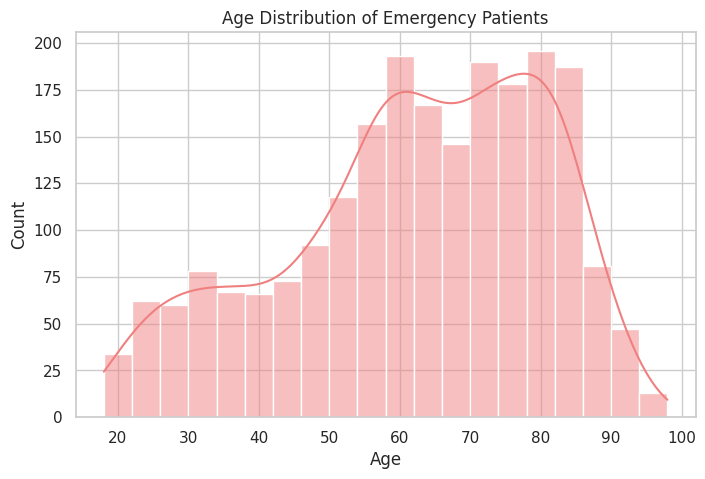

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True, color='lightcoral')

plt.title('Age Distribution of Emergency Patients')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

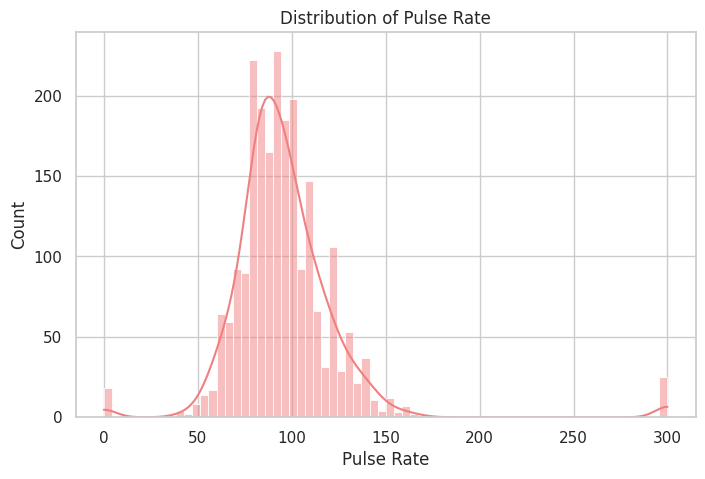

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['pulse'], kde=True, color='lightcoral')

plt.title('Distribution of Pulse Rate')
plt.xlabel('Pulse Rate')
plt.ylabel('Count')

plt.show()

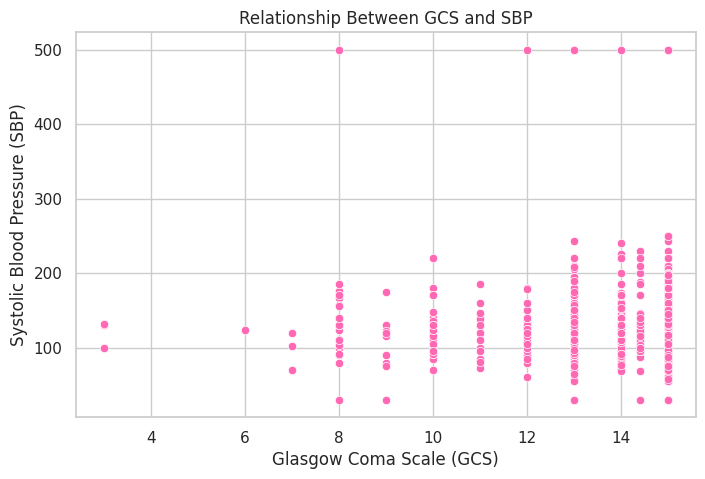

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='GCS', y='SBP', color='hotpink')

plt.title('Relationship Between GCS and SBP')
plt.xlabel('Glasgow Coma Scale (GCS)')
plt.ylabel('Systolic Blood Pressure (SBP)')

plt.show()

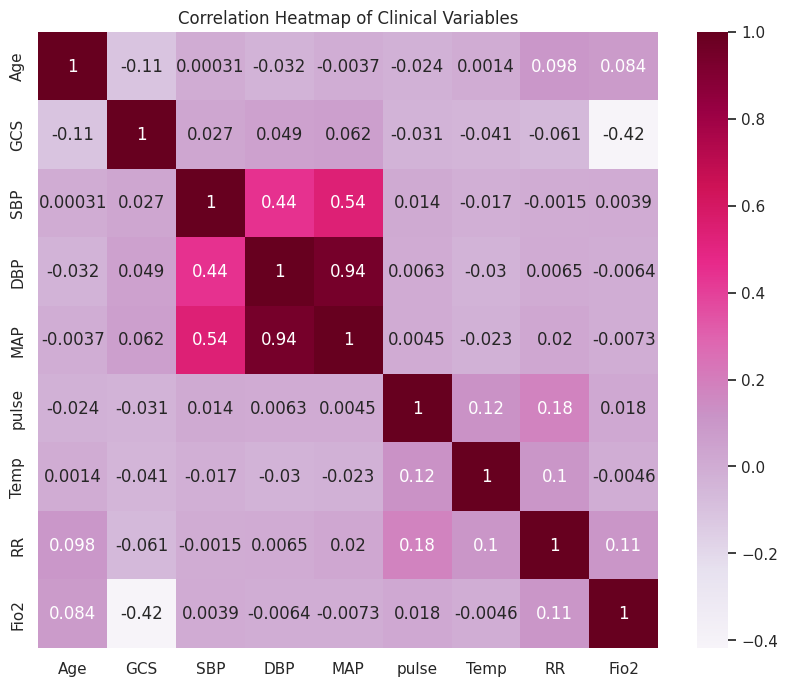

In [ ]:
plt.figure(figsize=(10,8))

# Columns that need to be converted to numeric
columns_to_convert = ['GCS', 'SBP', 'pulse', 'Temp']

# Convert problematic columns to numeric, coercing errors to NaN
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill any newly created NaNs (from coercion) with the column mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Calculate correlation after ensuring all relevant columns are numeric
corr = df[['Age','GCS','SBP','DBP','MAP','pulse','Temp','RR','Fio2']].corr()

sns.heatmap(corr, annot=True, cmap='PuRd') # Changed colormap to 'PuRd' for pink hues

plt.title('Correlation Heatmap of Clinical Variables')

plt.show()

***Interpretation***

The correlation heatmap displays relationships among the clinical variables in the dataset. Positive correlations indicate variables that increase together, while negative correlations indicate inverse relationships. This visualization helps identify possible clinical associations between patient vital signs and neurological condition.

***Conclusion***

This analysis successfully explored the emergency triage dataset using multiple clinical visualizations. The visualizations provided insights into patient demographics, cardiovascular measurements, neurological status, and relationships between clinical variables.

The GCS and SBP visualization was particularly important because it demonstrated the relationship between neurological function and blood pressure stability in emergency patients. Additionally, the correlation heatmap provided a broader understanding of interactions among vital signs.

Overall, clinical visualization is an effective method for understanding patient conditions and supporting emergency healthcare analysis.